In [1]:
############################################################################################################################
######     Plotting for figure 2,3,4 and the supplementary                                                        ##########
############################################################################################################################
# import modules
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import matplotlib.ticker as tick
# plt.style.use('ggplot') 
# plt.style.use('seaborn-paper') 
# plt.style.use('seaborn-whitegrid') 

np.set_printoptions(suppress=True)

2024-03-11 10:11:16.559916: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-11 10:11:16.559977: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-11 10:11:16.560004: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-11 10:11:16.566690: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Load data
dat=pd.read_csv("../synthetic_inference/model_fit_results.csv")
HMC=pd.read_csv("../synthetic_inference/model_hmc_results.csv")
# Add column names
dat.columns=["nbObs","truebeta1","truebeta2","repeat","betamean1",
             "betamean2","betastd1","betastd2","bcorr","z1","z2"]

In [5]:
dat.head()

,nbObs,truebeta1,truebeta2,repeat,betamean1,betamean2,betastd1,betastd2,bcorr,z1,z2
0,1000001,0.5,-0.8,0,0.500010,-0.817374,0.006176,0.014620,-0.001612,1.188365,NaN
1,1000001,-1.5,-1.8,0,-1.496962,-1.791255,0.006261,0.011311,-0.485259,-0.773092,NaN
2,1000001,-1.5,1.8,0,-1.503472,1.821741,0.006713,0.014540,0.517256,-1.495233,NaN
3,1000001,1.2,1.8,0,1.197741,1.784657,0.006775,0.014020,0.333471,1.094369,NaN
4,100001,0.5,-0.8,0,0.512915,-0.726829,0.023154,0.046837,-0.557806,-1.562255,NaN


In [6]:
# Calculate Z-score of betamean1 and betamean2
dat["Z1"]=(dat["betamean1"]-dat["truebeta1"])/dat["betastd1"]
dat["Z2"]=(dat["betamean2"]-dat["truebeta2"])/dat["betastd2"]

# Take the value of Z1 and Z2 put them in a long format
dat=pd.melt(dat,value_vars=["Z1","Z2"],var_name="Score",value_name="Z_score")

# Sort the values
dat=dat.sort_values(by=["Z_score"])

#Rank from the lowest to highest
dat["Rank"]=np.arange(1,dat.shape[0]+1,1)

# Calculate the percentiles
dat["Percentiles"]=(dat["Rank"]-0.5)/dat.shape[0]

# Calculate theoretical quantiles
dat["Theoretical_Z"]=stats.norm.ppf(dat["Percentiles"])

# Calculate Sample quantiles
dat["Sample_Z"]=(dat["Z_score"]-np.mean(dat["Z_score"]))/np.std(dat["Z_score"])

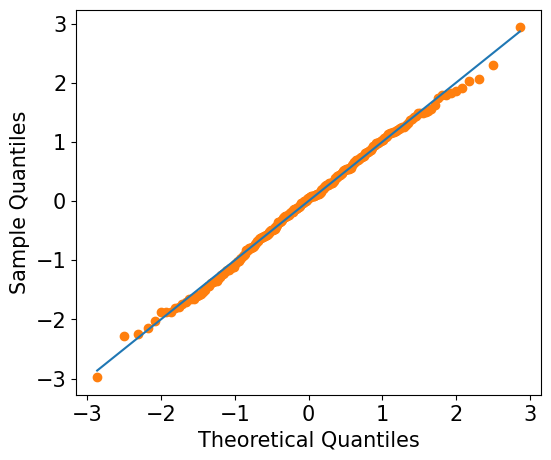

In [7]:
# Plotting QQ-plot
fig=plt.figure(figsize=(6,5))
plt.plot(dat["Theoretical_Z"],dat["Sample_Z"],"o",color="C1")
plt.plot(dat["Theoretical_Z"],dat["Theoretical_Z"]*1 + 0,color="C0")
plt.xlabel("Theoretical Quantiles",fontsize=15)
plt.ylabel("Sample Quantiles",fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
#plt.title("C)",fontsize=15)
plt.savefig("QQ-plot.png",dpi=300)
plt.show()

In [10]:
# Load data
dat=pd.read_csv("../synthetic_inference/model_fit_results.csv")
# Add column names
dat.columns=["nbObs","truebeta1","truebeta2","repeat","betamean1",
             "betamean2","betastd1","betastd2","bcorr","z1","z2"]

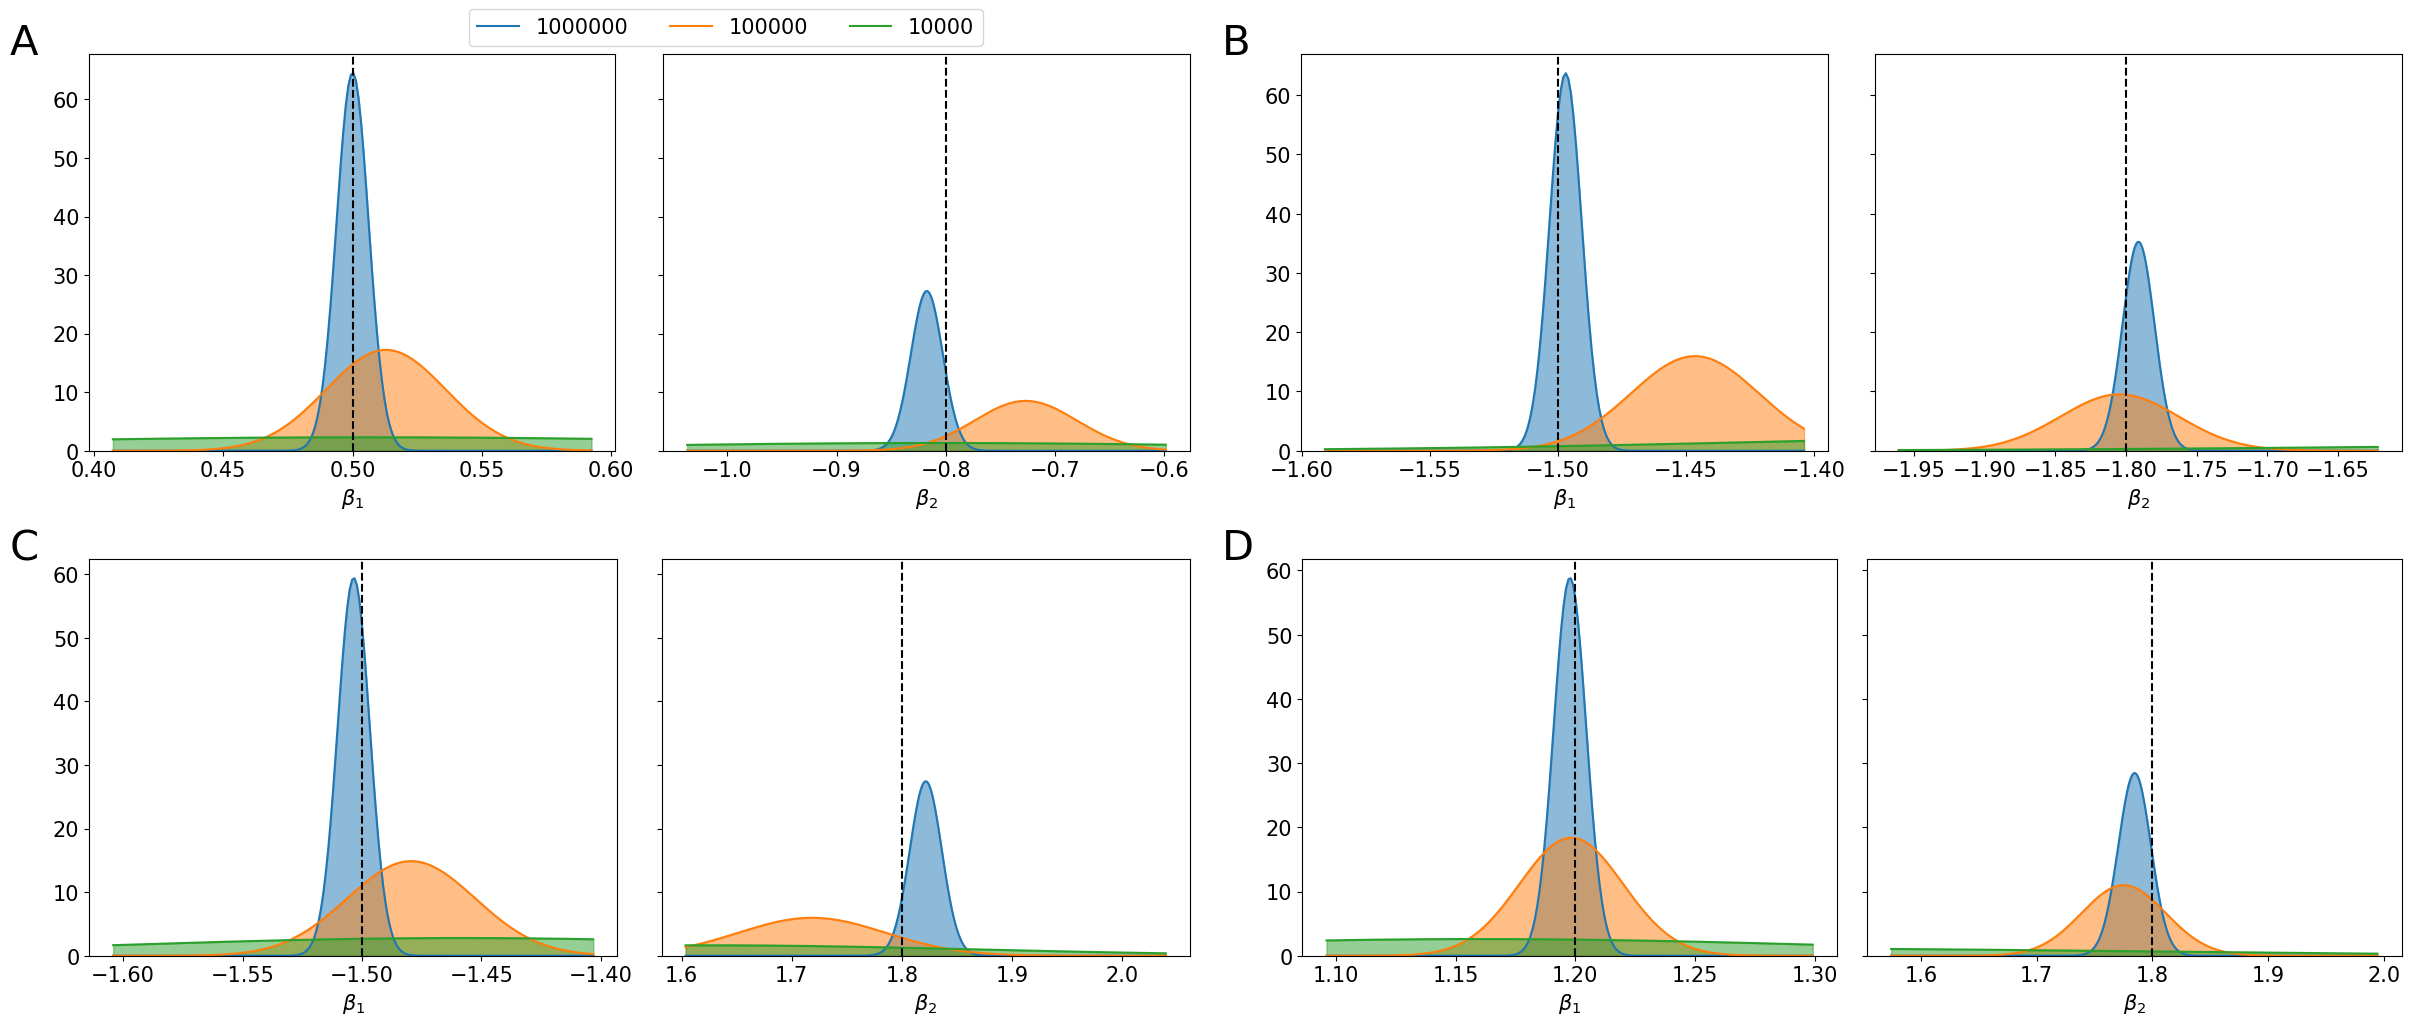

In [20]:
fig = plt.figure(constrained_layout=True,figsize=(24,10))
subfigs = fig.subfigures(2, 2)

mean_values = np.array([[list(dat.betamean1.iloc[0::4].values[:3]),list(dat.betamean2.iloc[0::4].values[:3])],
                        [list(dat.betamean1.iloc[1::4].values[:3]),list(dat.betamean2.iloc[1::4].values[:3])],
                        [list(dat.betamean1.iloc[2::4].values[:3]),list(dat.betamean2.iloc[2::4].values[:3])],
                        [list(dat.betamean1.iloc[3::4].values[:3]),list(dat.betamean2.iloc[3::4].values[:3])]])

std_values = np.array([[list(dat.betastd1.iloc[0::4].values[:3]),list(dat.betastd2.iloc[0::4].values[:3])],
                        [list(dat.betastd1.iloc[1::4].values[:3]),list(dat.betastd2.iloc[1::4].values[:3])],
                        [list(dat.betastd1.iloc[2::4].values[:3]),list(dat.betastd2.iloc[2::4].values[:3])],
                        [list(dat.betastd1.iloc[3::4].values[:3]),list(dat.betastd2.iloc[3::4].values[:3])]])

# mean_values = np.array([[[0.4523672,0.49568135,0.50597334],[-0.79752296,-0.75204116,-0.7916548]],
#                         [[-1.536537,-1.4717115,-1.4932564],[-1.7603903,-1.757564,-1.7819358]],
#                         [[-1.4757782,-1.4643744,-1.4891123],[1.7954538,1.7426754,1.790077]],
#                         [[1.2062879,1.2156487,1.195252],[1.83986,1.7971259,1.8167716]]])

# std_values = np.array([[[0.13515954,0.03478395,0.01365028],[0.14592543,0.03698448,0.01457316]],
#                         [[0.15595654,0.02870001,0.01407821],[0.16576165,0.04073759,0.01434045]],
#                         [[0.14176352,0.03710392,0.01332322],[0.15046774,0.03841416,0.01433117]],
#                         [[0.14018877,0.03553431,0.0136965],[0.15522479,0.04666927,0.01844882]]])

true_values = np.array([[0.5,-0.8],[-1.5,-1.8],[-1.5,1.8],[1.2,1.8]])

labels = ['A','B','C','D']
colors = ['C0','C1','C2']
xlabels = [r"$\beta_1$", r"$\beta_2$"]

for outerind, subfig in enumerate(subfigs.flat):
    axs = subfig.subplots(1, 2,sharey=True)
    
    axs[0].text(-0.15,1,labels[outerind], size=30, transform=axs[0].transAxes)
    
    panel_means = mean_values[outerind]
    panel_std = std_values[outerind]
    lines = []  # Empty list to hold proxy artists for legend
    for i in range(2):
        xmin = panel_means[i][0] - 15* panel_std[i][0]
        xmax = panel_means[i][0] + 15* panel_std[i][0]

    
        # Positive-Negative coefficients
        x = np.arange(xmin,xmax,0.001)
        
        for j in range(3):
            dist = tfp.distributions.Normal(loc=panel_means[i,j],scale=panel_std[i,j]).prob(x)
            #axs[i].plot(x,dist,c=colors[j])
            # Save line for legend
            line, = axs[i].plot(x, dist, c=colors[j])  
            # Append line to list
            lines.append(line) 
            axs[i].fill_between(x,dist,color=colors[j],alpha=0.5)
        axs[i].axvline(true_values[outerind,i],c='black',ls='--')
        axs[i].set_ylim(0,None)#PPM.numpy().max()*1.05)
        axs[i].tick_params(axis='both', which='major', labelsize=15)
        axs[i].set_xlabel(xlabels[i],fontsize=15)

# Adding legend
fig.legend(lines, ["1000000", "100000","10000"],ncol=3, 
           bbox_to_anchor=(0.3, 1.01),loc="upper center", borderaxespad=0.,fontsize=15)
plt.savefig('Figure_2_R.png',dpi=300)

plt.show()

In [2]:
# HMC Posterior distribution
PN=np.load("../synthetic_inference/hmc_samples_10001_b1_0.5_b2_-0.8.npy")
NN=PP=np.load("../synthetic_inference/hmc_samples_10001_b1_-1.5_b2_-1.8.npy")
NP=np.load("../synthetic_inference/hmc_samples_10001_b1_-1.5_b2_1.8.npy")
PP=np.load("../synthetic_inference/hmc_samples_10001_b1_1.2_b2_1.8.npy")

In [3]:
PN=np.squeeze(PN)
PN=np.reshape(PN,(-1,2))
NN=np.squeeze(NN)
NN=np.reshape(NN,(-1,2))
NP=np.squeeze(NP)
NP=np.reshape(NP,(-1,2))
PP=np.squeeze(PP)
PP=np.reshape(PP,(-1,2))

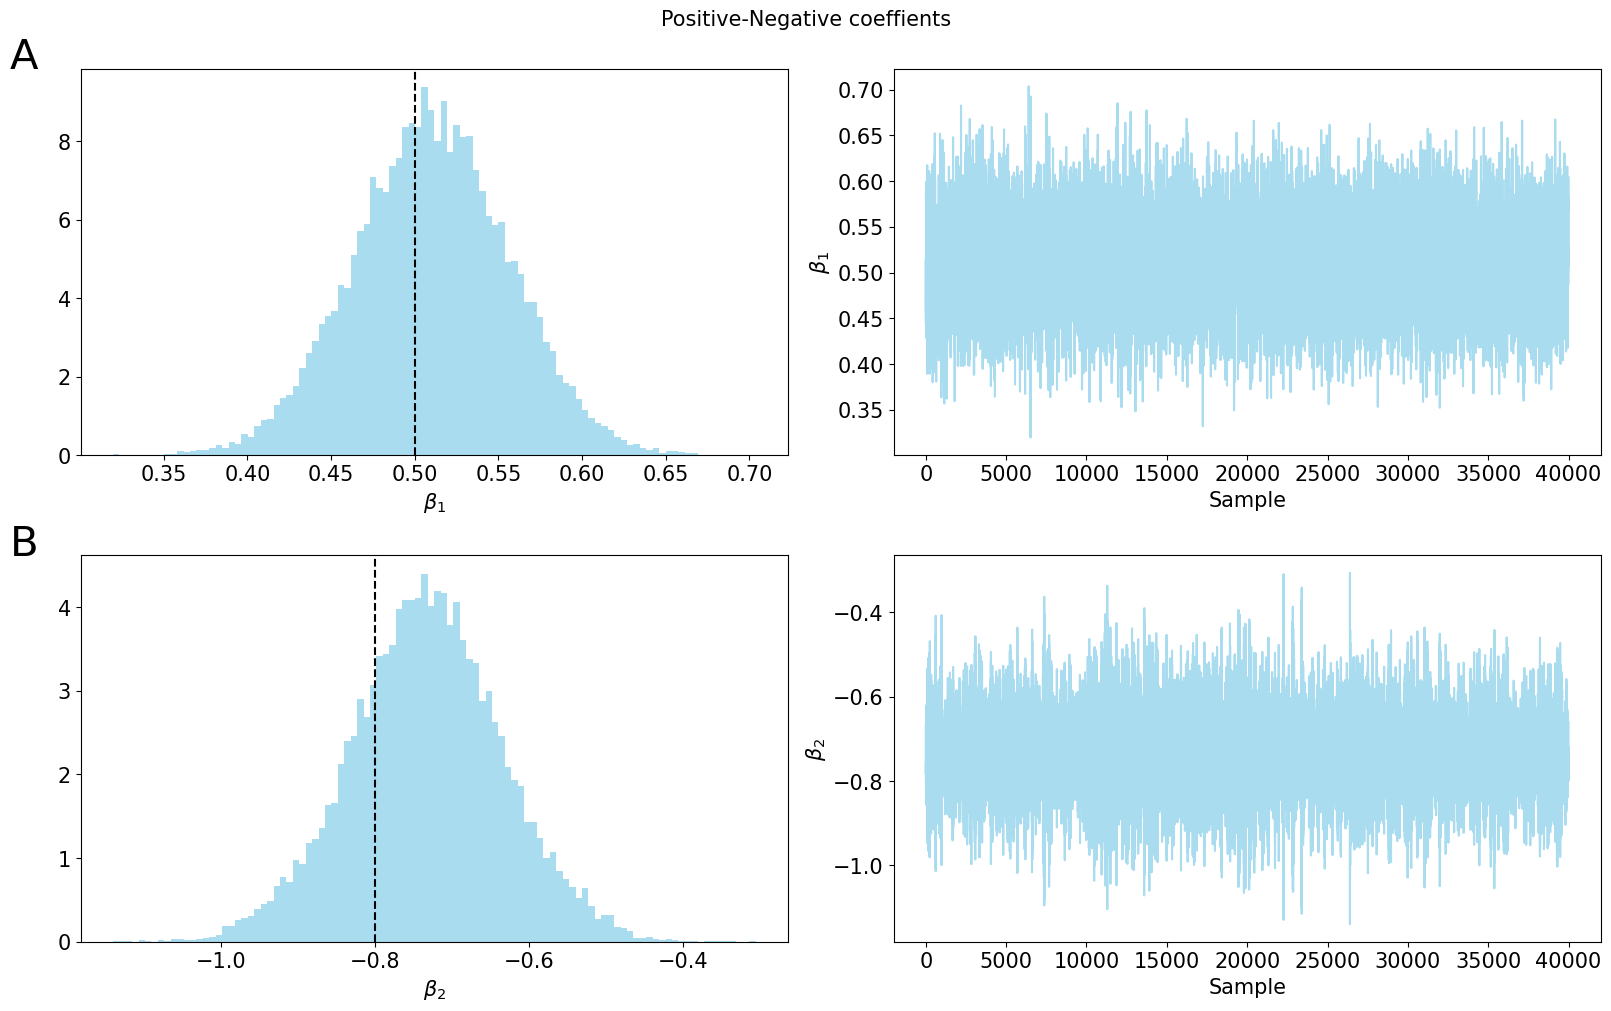

In [30]:
fig, ax = plt.subplots(2, 2,figsize=(16,10),constrained_layout=True)

# Beta 1
ax[0][0].hist(PN[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[0][1].plot(PN[:,0], color="skyblue", alpha=0.7)
ax[0][0].axvline(0.5,c='black', linestyle='--')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


# Beta 2
ax[1][0].hist(PN[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][1].plot(PN[:,1], color="skyblue", alpha=0.7)
ax[1][0].axvline(-0.8,c='black', linestyle='--')
ax[1][0].set_ylabel("")
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)
#fig.subplots_adjust(wspace=0.2, hspace=0.3)
fig.suptitle("Positive-Negative coeffients",fontsize=15)
plt.savefig("Post-plotPP.png",dpi=300)

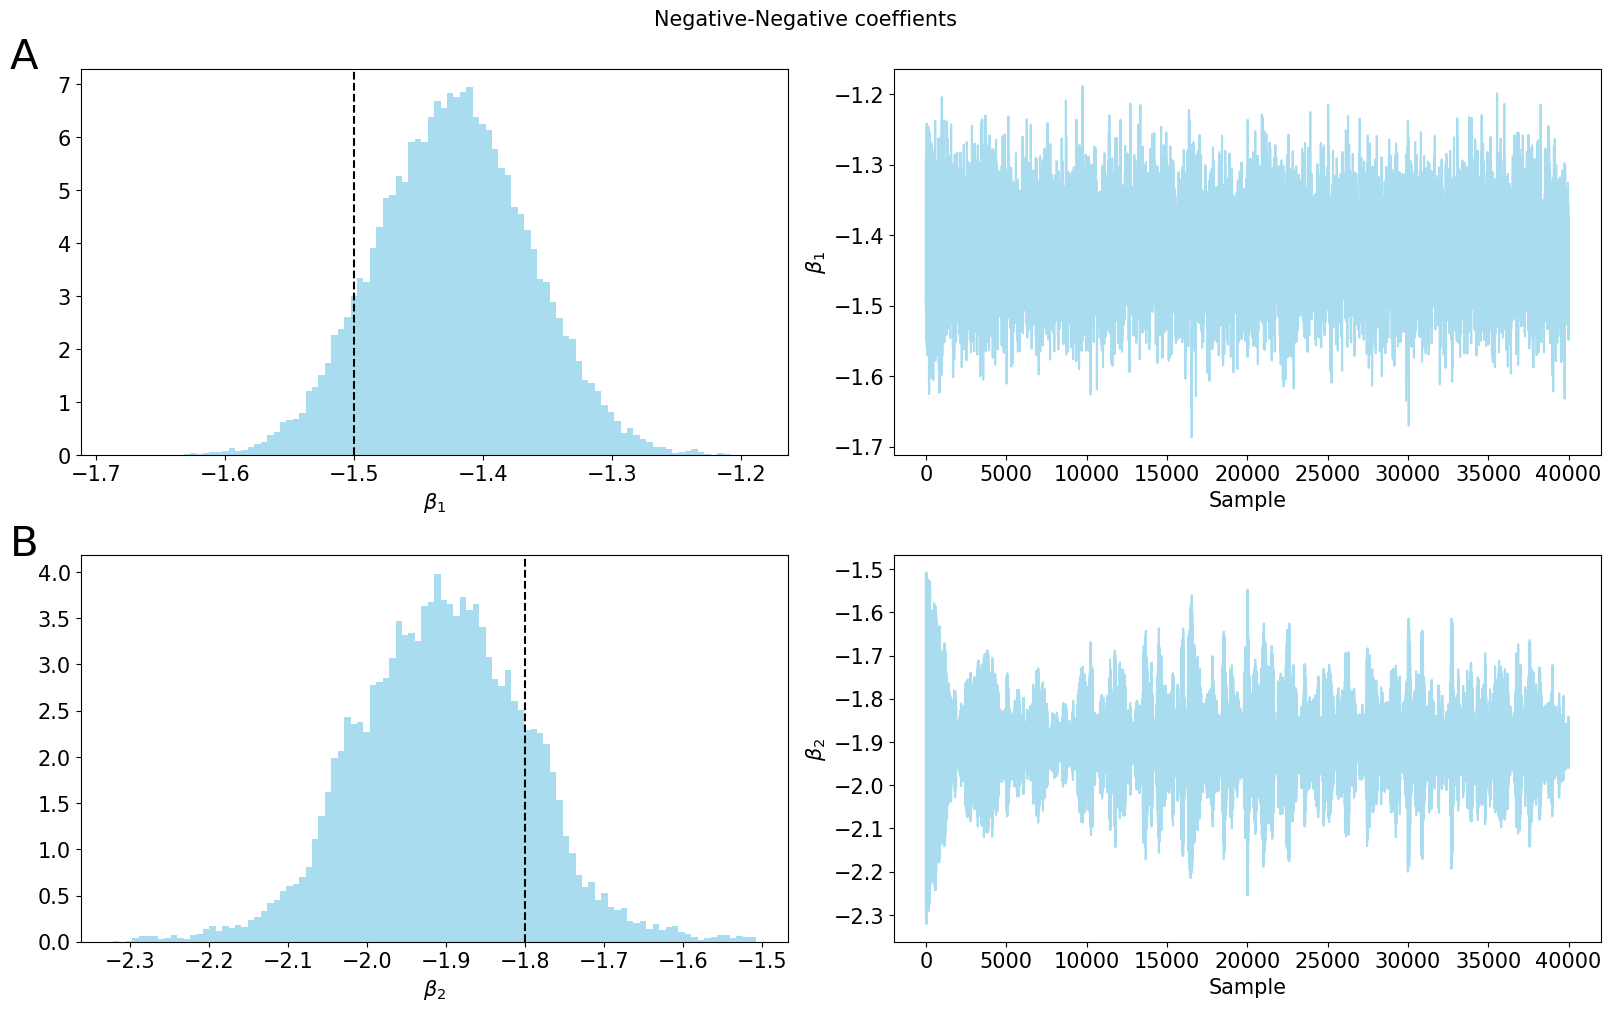

In [32]:
fig, ax = plt.subplots(2, 2,figsize=(16,10),constrained_layout=True)

# Beta 1
ax[0][0].hist(NN[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[0][1].plot(NN[:,0], color="skyblue", alpha=0.7)
ax[0][0].axvline(-1.5,c='black', linestyle='--')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


# Beta 2
ax[1][0].hist(NN[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][1].plot(NN[:,1], color="skyblue", alpha=0.7)
ax[1][0].axvline(-1.8,c='black', linestyle='--')
ax[1][0].set_ylabel("")
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)
#fig.subplots_adjust(wspace=0.2, hspace=0.3)
fig.suptitle("Negative-Negative coeffients",fontsize=15)
plt.savefig("Post-plotNN.png",dpi=300)

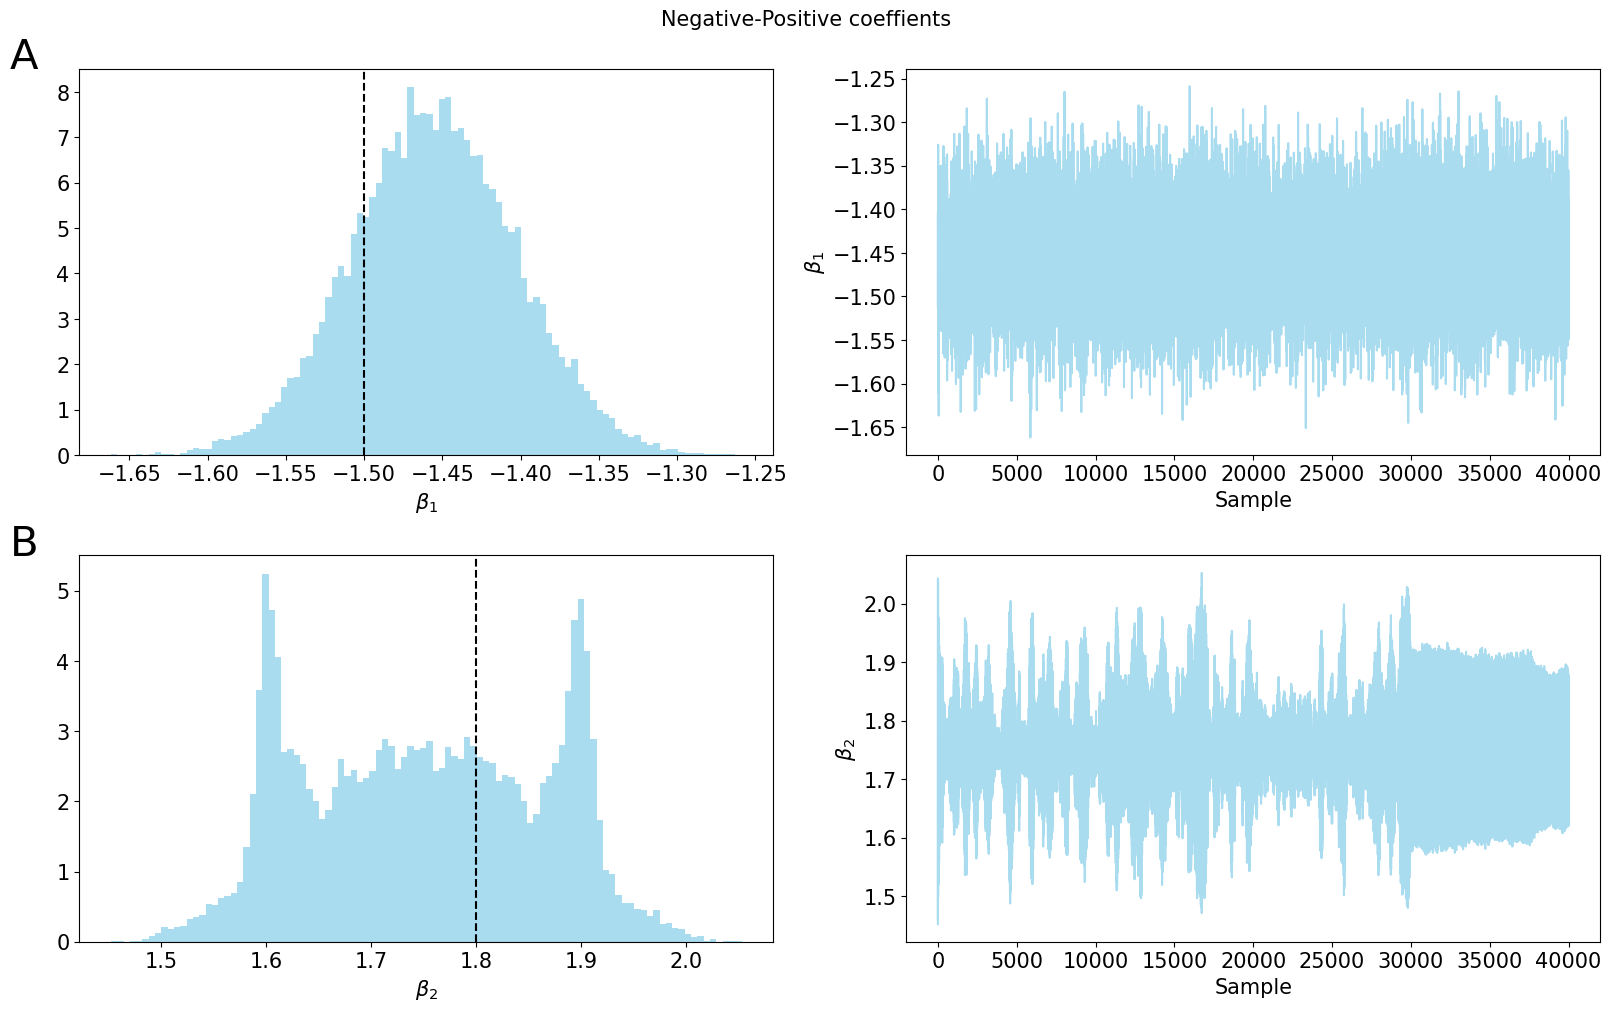

In [33]:
fig, ax = plt.subplots(2, 2,figsize=(16,10),constrained_layout=True)

# Beta 1
ax[0][0].hist(NP[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[0][1].plot(NP[:,0], color="skyblue", alpha=0.7)
ax[0][0].axvline(-1.5,c='black', linestyle='--')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


# Beta 2
ax[1][0].hist(NP[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][1].plot(NP[:,1], color="skyblue", alpha=0.7)
ax[1][0].axvline(1.8,c='black', linestyle='--')
ax[1][0].set_ylabel("")
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)
#fig.subplots_adjust(wspace=0.2, hspace=0.3)
fig.suptitle("Negative-Positive coeffients",fontsize=15)
plt.savefig("Post-plotNP.png",dpi=300)

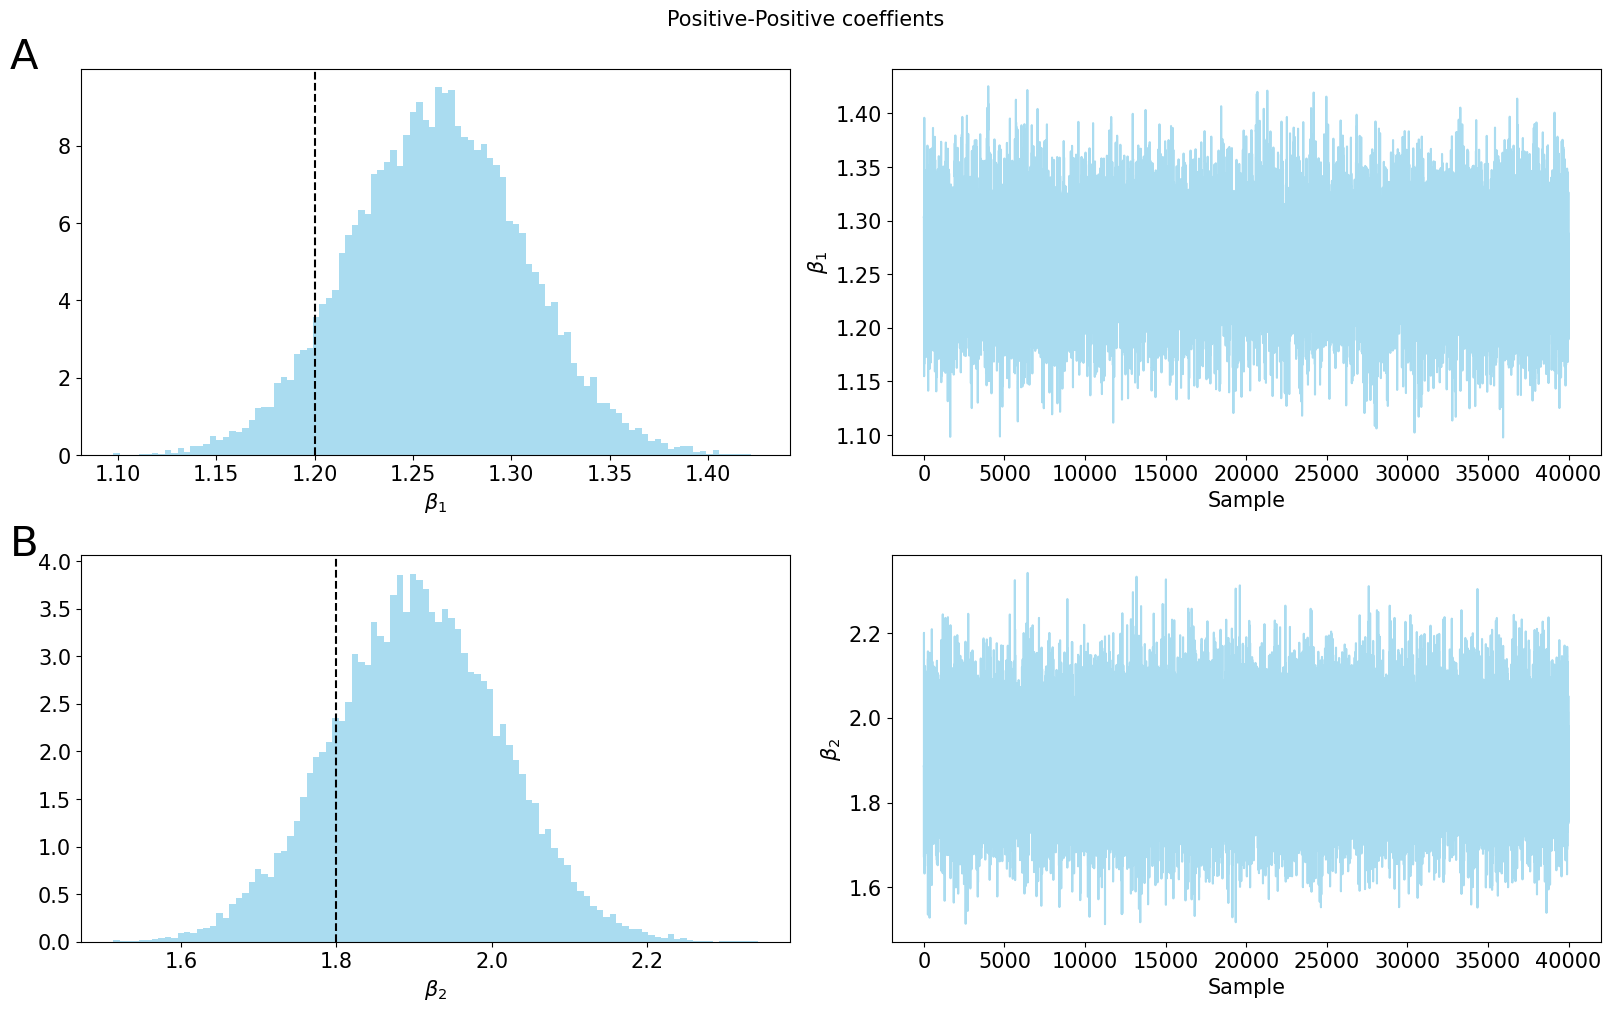

In [34]:
fig, ax = plt.subplots(2, 2,figsize=(16,10),constrained_layout=True)

# Beta 1
ax[0][0].hist(PP[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[0][1].plot(PP[:,0], color="skyblue", alpha=0.7)
ax[0][0].axvline(1.2,c='black', linestyle='--')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=30, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][1].set_xlabel("Sample", fontsize=15)
ax[0][1].set_ylabel(r"$\beta_1$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


# Beta 2
ax[1][0].hist(PP[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][1].plot(PP[:,1], color="skyblue", alpha=0.7)
ax[1][0].axvline(1.8,c='black', linestyle='--')
ax[1][0].set_ylabel("")
ax[1][0].text(-0.1,1,'B', size=30, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][1].set_xlabel("Sample", fontsize=15)
ax[1][1].set_ylabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)
#fig.subplots_adjust(wspace=0.2, hspace=0.3)
fig.suptitle("Positive-Positive coeffients",fontsize=15)
plt.savefig("Post-plotPP.png",dpi=300)

In [2]:
# Load data
VI=pd.read_csv("../synthetic_inference/model_fit_results.csv")
HMC=pd.read_csv("../synthetic_inference/model_hmc_results.csv")
# Add column names
VI.columns=["nbObs","truebeta1","truebeta2","repeat","betamean1","betamean2","betastd1","betastd2"]
HMC.columns=["nbObs", "truebeta1", "truebeta2", "betamean1", "betamean2","betastd1", "betastd2"]

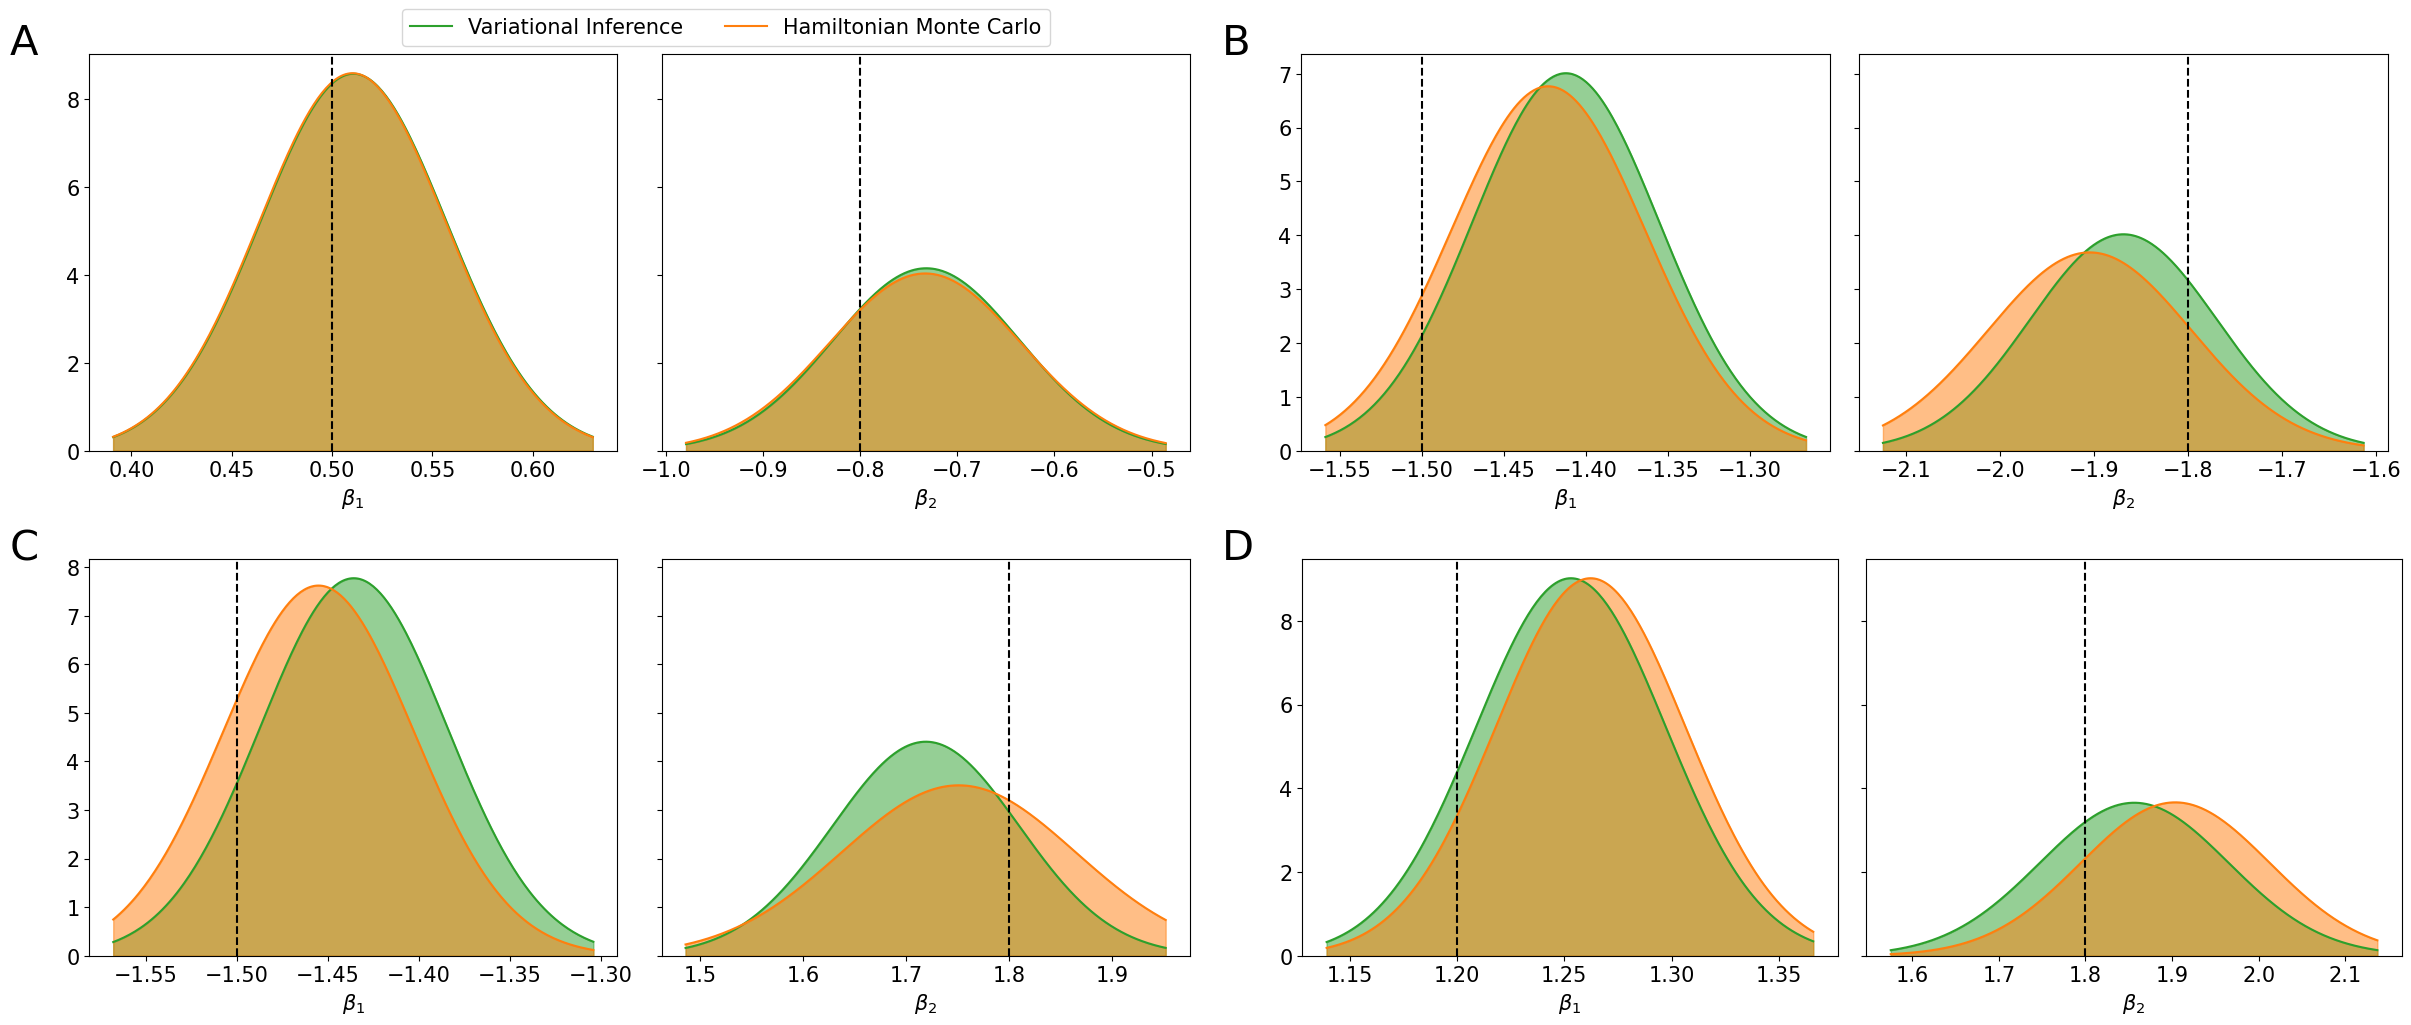

In [9]:
fig = plt.figure(constrained_layout=True,figsize=(24,10))
subfigs = fig.subfigures(2, 2)

mean_values = np.array([[list([VI.betamean1.iloc[0],HMC.betamean1.iloc[0]]),list([VI.betamean2.iloc[0],HMC.betamean2.iloc[0]])],
                        [list([VI.betamean1.iloc[1],HMC.betamean1.iloc[1]]),list([VI.betamean2.iloc[1],HMC.betamean2.iloc[1]])],
                        [list([VI.betamean1.iloc[2],HMC.betamean1.iloc[2]]),list([VI.betamean2.iloc[2],HMC.betamean2.iloc[2]])],
                        [list([VI.betamean1.iloc[3],HMC.betamean1.iloc[3]]),list([VI.betamean2.iloc[3],HMC.betamean2.iloc[3]])]])

std_values =  np.array([[list([VI.betastd1.iloc[0],HMC.betastd1.iloc[0]]),list([VI.betastd2.iloc[0],HMC.betastd2.iloc[0]])],
                        [list([VI.betastd1.iloc[1],HMC.betastd1.iloc[1]]),list([VI.betastd2.iloc[1],HMC.betastd2.iloc[1]])],
                        [list([VI.betastd1.iloc[2],HMC.betastd1.iloc[2]]),list([VI.betastd2.iloc[2],HMC.betastd2.iloc[2]])],
                        [list([VI.betastd1.iloc[3],HMC.betastd1.iloc[3]]),list([VI.betastd2.iloc[3],HMC.betastd2.iloc[3]])]])


true_values = np.array([[0.5,-0.8],[-1.5,-1.8],[-1.5,1.8],[1.2,1.8]])

labels = ['A','B','C','D']
colors = ['C2','C1']
xlabels = [r"$\beta_1$", r"$\beta_2$"]

for outerind, subfig in enumerate(subfigs.flat):
    axs = subfig.subplots(1, 2,sharey=True)
    
    axs[0].text(-0.15,1,labels[outerind], size=30, transform=axs[0].transAxes)
    
    panel_means = mean_values[outerind]
    panel_std = std_values[outerind]
    lines = []  # Empty list to hold proxy artists for legend
    for i in range(2):
        xmin = panel_means[i][0] - 2.576* panel_std[i][0]
        xmax = panel_means[i][0] + 2.576* panel_std[i][0]

    
        # Positive-Negative coefficients
        x = np.arange(xmin,xmax,0.001)
        
        for j in range(2):
            dist = tfp.distributions.Normal(loc=panel_means[i,j],scale=panel_std[i,j]).prob(x)
        
            #axs[i].plot(x,dist,c=colors[j])
            # Save line for legend
            line, = axs[i].plot(x, dist, c=colors[j])  
            # Append line to list
            lines.append(line)  
            axs[i].fill_between(x,dist,color=colors[j],alpha=0.5)
        axs[i].axvline(true_values[outerind,i],c='black',ls='--')
        axs[i].set_ylim(0,None)
        axs[i].tick_params(axis='both', which='major', labelsize=15)
        axs[i].set_xlabel(xlabels[i],fontsize=15)

# Adding legend
fig.legend(lines, ['Variational Inference', 'Hamiltonian Monte Carlo'],ncol=2, 
           bbox_to_anchor=(0.3, 1.01),loc="upper center", borderaxespad=0.,fontsize=15)

plt.savefig('Figure_HMCVI.png',dpi=300)

plt.show()

In [5]:
# HMC Posterior distribution
PN=np.load("../synthetic_inference/hmc_samples_10001_b1_0.5_b2_-0.8.npy")
NN=PP=np.load("../synthetic_inference/hmc_samples_10001_b1_-1.5_b2_-1.8.npy")
NP=np.load("../synthetic_inference/hmc_samples_10001_b1_-1.5_b2_1.8.npy")
PP=np.load("../synthetic_inference/hmc_samples_10001_b1_1.2_b2_1.8.npy")
VI=pd.read_csv("../synthetic_inference/model_fit_results.csv")
# Add column names
VI.columns=["nbObs","truebeta1","truebeta2","repeat","betamean1","betamean2","betastd1","betastd2"]

In [7]:
PN=np.squeeze(PN)
PN=np.reshape(PN,(-1,2))
NN=np.squeeze(NN)
NN=np.reshape(NN,(-1,2))
NP=np.squeeze(NP)
NP=np.reshape(NP,(-1,2))
PP=np.squeeze(PP)
PP=np.reshape(PP,(-1,2))

/tmp/ipykernel_2903/1421137389.py:144: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.2, hspace=0.3)


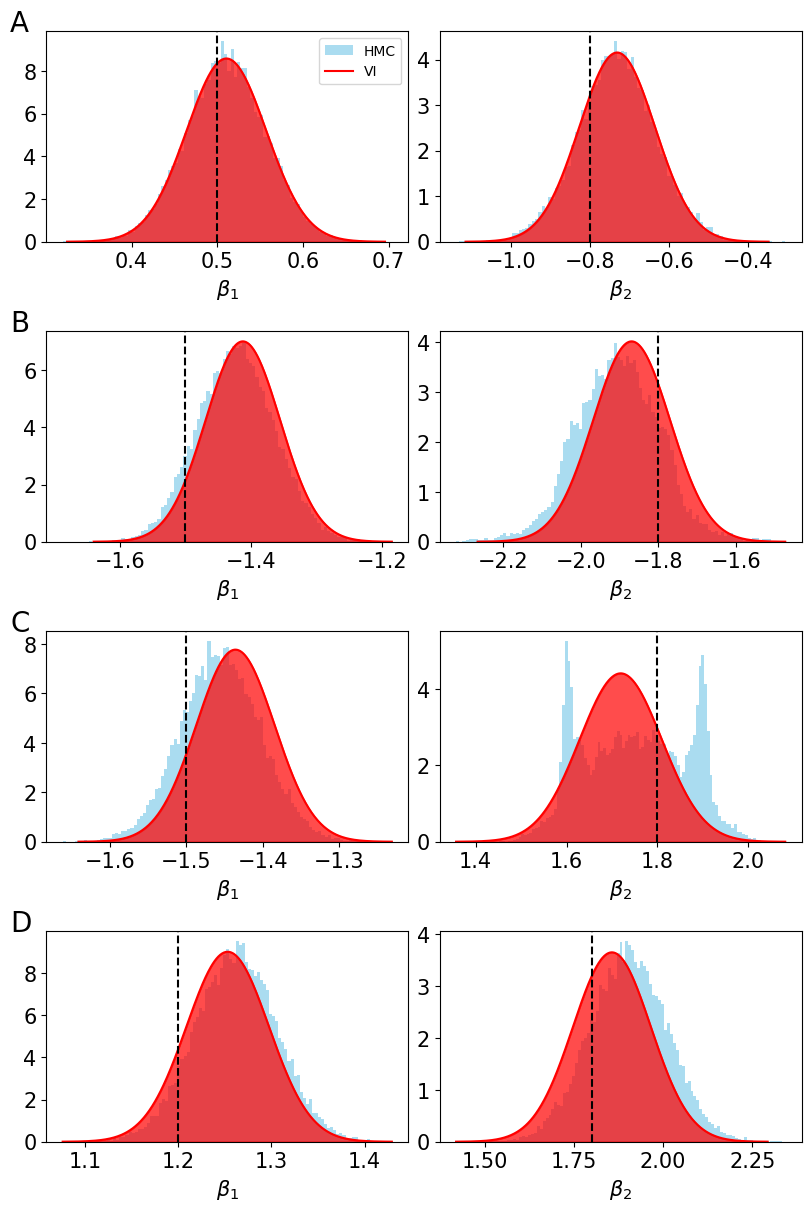

In [46]:
# Hstogram of VI and HMC

fig, ax = plt.subplots(4, 2,figsize=(8,12),constrained_layout=True)

# "Positive-Positive coeffients"
xmin = VI.betamean1.iloc[0] - 4* VI.betastd1.iloc[0]
xmax = VI.betamean1.iloc[0] + 4*VI.betastd1.iloc[0]

x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean1.iloc[0],scale=VI.betastd1.iloc[0]).prob(x)

#Beta 1
ax[0][0].hist(PN[:,0],bins=100,density=True,color="skyblue",alpha=0.7,label="HMC")
ax[0][0].plot(x,dist,c="red",label="VI")
ax[0][0].fill_between(x,dist,color='red',alpha=0.7)
ax[0][0].axvline(0.5,c='black', linestyle='--')
ax[0][0].set_ylabel("")
ax[0][0].text(-0.1,1,'A', size=20, transform=ax[0][0].transAxes)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][0].legend(loc="best")

#Beta 2
xmin = VI.betamean2.iloc[0] - 4* VI.betastd2.iloc[0]
xmax = VI.betamean2.iloc[0] + 4*VI.betastd2.iloc[0]
x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean2.iloc[0],scale=VI.betastd2.iloc[0]).prob(x)

ax[0][1].hist(PN[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[0][1].plot(x,dist,c="red")
ax[0][1].fill_between(x,dist,color='red',alpha=0.7)
ax[0][1].axvline(-0.8,c='black', linestyle='--')
ax[0][1].set_ylabel("")
ax[0][1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)


# "Negative-Negative coeffients"
xmin = VI.betamean1.iloc[1] - 4* VI.betastd1.iloc[1]
xmax = VI.betamean1.iloc[1] + 4*VI.betastd1.iloc[1]

x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean1.iloc[1],scale=VI.betastd1.iloc[1]).prob(x)

#Beta 1
ax[1][0].hist(NN[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][0].plot(x,dist,c="red")
ax[1][0].fill_between(x,dist,color='red',alpha=0.7)
ax[1][0].axvline(-1.5,c='black', linestyle='--')
ax[1][0].set_ylabel("")
ax[1][0].text(-0.1,1,'B', size=20, transform=ax[1][0].transAxes)
ax[1][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)
ax[1][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)


#Beta 2
xmin = VI.betamean2.iloc[1] - 4* VI.betastd2.iloc[1]
xmax = VI.betamean2.iloc[1] + 4*VI.betastd2.iloc[1]
x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean2.iloc[1],scale=VI.betastd2.iloc[1]).prob(x)

ax[1][1].hist(NN[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[1][1].plot(x,dist,c="red")
ax[1][1].fill_between(x,dist,color='red',alpha=0.7)
ax[1][1].axvline(-1.8,c='black', linestyle='--')
ax[1][1].set_ylabel("")
ax[1][1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)


# "Negative-Positive coeffients"
xmin = VI.betamean1.iloc[2] - 4* VI.betastd1.iloc[2]
xmax = VI.betamean1.iloc[2] + 4*VI.betastd1.iloc[2]

x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean1.iloc[2],scale=VI.betastd1.iloc[2]).prob(x)

#Beta 1
ax[2][0].hist(NP[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[2][0].plot(x,dist,c="red")
ax[2][0].fill_between(x,dist,color='red',alpha=0.7)
ax[2][0].axvline(-1.5,c='black', linestyle='--')
ax[2][0].set_ylabel("")
ax[2][0].text(-0.1,1,'C', size=20, transform=ax[2][0].transAxes)
ax[2][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[2][0].tick_params(axis='both', which='major', labelsize=15)
ax[2][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[2][0].tick_params(axis='both', which='major', labelsize=15)


#Beta 2
xmin = VI.betamean2.iloc[2] - 4* VI.betastd2.iloc[2]
xmax = VI.betamean2.iloc[2] + 4*VI.betastd2.iloc[2]
x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean2.iloc[2],scale=VI.betastd2.iloc[2]).prob(x)

ax[2][1].hist(NP[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[2][1].plot(x,dist,c="red")
ax[2][1].fill_between(x,dist,color='red',alpha=0.7)
ax[2][1].axvline(1.8,c='black', linestyle='--')
ax[2][1].set_ylabel("")
ax[2][1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[2][1].tick_params(axis='both', which='major', labelsize=15)


# "Positive-Positive coeffients"
xmin = VI.betamean1.iloc[3] - 4* VI.betastd1.iloc[3]
xmax = VI.betamean1.iloc[3] + 4*VI.betastd1.iloc[3]

x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean1.iloc[3],scale=VI.betastd1.iloc[3]).prob(x)

#Beta 1
ax[3][0].hist(PP[:,0],bins=100,density=True,color="skyblue",alpha=0.7)
ax[3][0].plot(x,dist,c="red")
ax[3][0].fill_between(x,dist,color='red',alpha=0.7)
ax[3][0].axvline(1.2,c='black', linestyle='--')
ax[3][0].set_ylabel("")
ax[3][0].text(-0.1,1,'D', size=20, transform=ax[3][0].transAxes)
ax[3][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[3][0].tick_params(axis='both', which='major', labelsize=15)
ax[3][0].set_xlabel(r"$\beta_1$", fontsize=15)
ax[3][0].tick_params(axis='both', which='major', labelsize=15)


#Beta 2
xmin = VI.betamean2.iloc[3] - 4* VI.betastd2.iloc[3]
xmax = VI.betamean2.iloc[3] + 4*VI.betastd2.iloc[3]
x = np.arange(xmin,xmax,0.001)
dist= tfp.distributions.Normal(loc=VI.betamean2.iloc[3],scale=VI.betastd2.iloc[3]).prob(x)

ax[3][1].hist(PP[:,1],bins=100,density=True,color="skyblue",alpha=0.7)
ax[3][1].plot(x,dist,c="red")
ax[3][1].fill_between(x,dist,color='red',alpha=0.7)
ax[3][1].axvline(1.8,c='black', linestyle='--')
ax[3][1].set_ylabel("")
ax[3][1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[3][1].tick_params(axis='both', which='major', labelsize=15)

fig.subplots_adjust(wspace=0.2, hspace=0.3)
# fig.suptitle("Positive-Positive coeffients",fontsize=15)
plt.savefig("VIhmc.png",dpi=300)
plt.show()

2023-03-07 14:07:58.587879: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-07 14:07:59.069181: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 263 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5


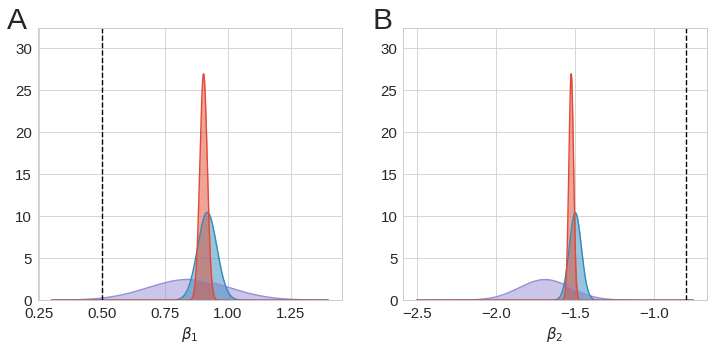

In [5]:
# Plotting probability density of 10000,100000,1000000 for step selection model without midpoints
x = np.arange(0.3,1.4,0.001)
sK= tfp.distributions.Normal(loc=0.84529182,scale=0.16132132).prob(x)
sL = tfp.distributions.Normal(loc=0.9187723,scale=0.03811273).prob(x)
sM = tfp.distributions.Normal(loc=0.9040976,scale=0.01479852).prob(x)

fig,ax=plt.subplots(1,2, figsize=(12,5))
ax[0].plot(x,sK,c='C2')
ax[0].plot(x,sL,c='C1')
ax[0].plot(x,sM,c='C0')
ax[0].fill_between(x,sK,color='C2',alpha=0.5)
ax[0].fill_between(x,sL,color='C1',alpha=0.5)
ax[0].fill_between(x,sM,color='C0',alpha=0.5)
ax[0].axvline(0.5,c='black',ls='--')
ax[0].set_ylim(0,sM.numpy().max()*1.2)
ax[0].set_xlabel(r"$\beta_1$",fontsize=15)
ax[0].text(-0.1,1,'A', size=30, transform=ax[0].transAxes)
ax[0].tick_params(axis='both', which='major', labelsize=15)
#ax[0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             #fontsize=14,title_fontsize=16)

x = np.arange(-2.5,-0.75,0.001)
sK1= tfp.distributions.Normal(loc=-1.689274,scale=0.16246870).prob(x)
sL1= tfp.distributions.Normal(loc=-1.497402,scale=0.03827346).prob(x)
sM1= tfp.distributions.Normal(loc=-1.523381,scale=0.01479742).prob(x)

ax[1].plot(x,sK1,c='C2')
ax[1].plot(x,sL1,c='C1')
ax[1].plot(x,sM1,c='C0')
ax[1].fill_between(x,sK1,color='C2',alpha=0.5)
ax[1].fill_between(x,sL1,color='C1',alpha=0.5)
ax[1].fill_between(x,sM1,color='C0',alpha=0.5)
ax[1].axvline(-0.8,c='black',ls='--')
ax[1].set_ylim(0,sM1.numpy().max()*1.2)
ax[1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1].text(-0.1,1,'B', size=30, transform=ax[1].transAxes)
ax[1].tick_params(axis='both', which='major', labelsize=15)
plt.savefig('MSSF.png')
plt.show()